In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from LoadTSV import *

In [36]:
Moments = [4, 8, 12] #![4, 6, 8, 10, 12]
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1
chi_vector = [-1.0, 0.0, 1.0, 1.5, 2.0, 3.0, "optimal"]

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

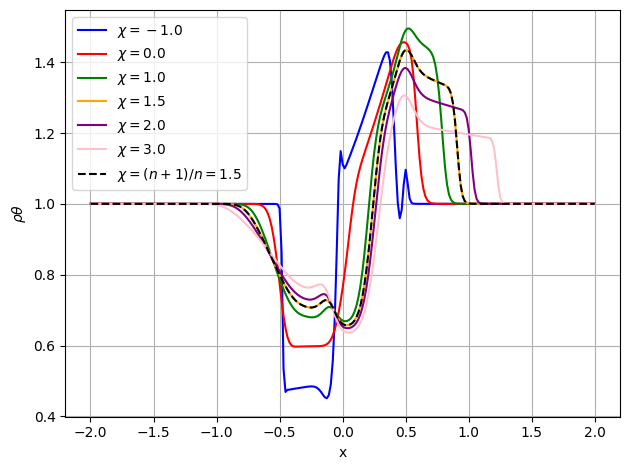

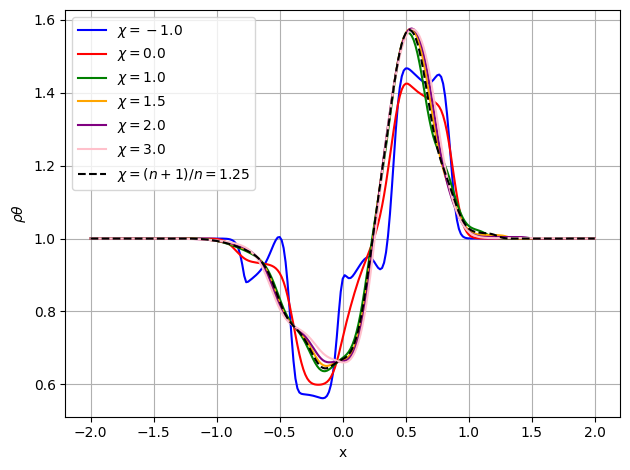

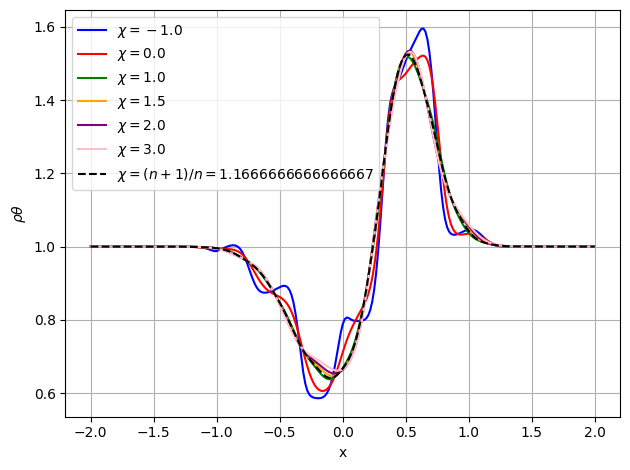

In [39]:
colors = ['blue', 'red', 'green', 'orange', 'purple', 'pink', 'black']
linestyles = 6 * ['solid'] + ['dashed']

for M in Moments:
    fig, axs = plt.subplots()
    for i, chi in enumerate(chi_vector):
        filename = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chi{chi}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'

        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, w, t = sol["x"], sol["u"], sol["t"]

        label = f"$\\chi={chi}$"
        if chi == "optimal":
            label = f"$\\chi=(n+1)/n={1+2/M}$"
        axs.plot(x, w[:,2], color=colors[i], linestyle=linestyles[i], label=label)

    axs.set_xlabel("x")
    axs.set_ylabel("$\\rho \\theta$")
    axs.grid(True)
    axs.legend()
    fig.tight_layout()
    fig.savefig('../out/Figures/GaugeInvestigation/GaugeInvestigation_M'+str(M)+'.pdf')
    fig.show()

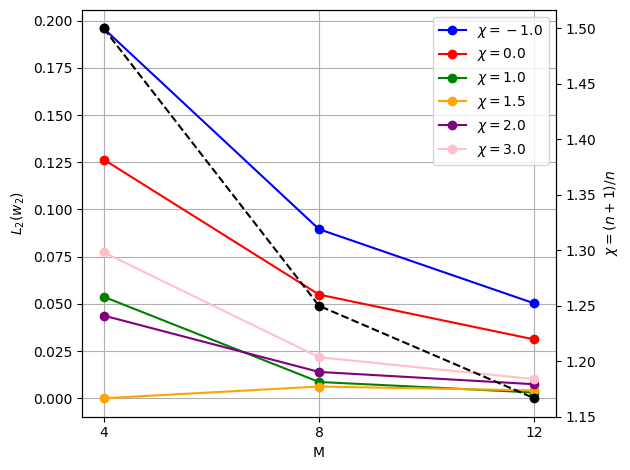

In [40]:
fig, axs = plt.subplots()
for i, chi in enumerate(chi_vector[:-1]):   # skip optimal, as this is our reference solution
    L2_error = []
    for j, M in enumerate(Moments):
        filename = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chi{chi}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'

        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, w, t = sol["x"], sol["u"], sol["t"]

        # Load optimal solution
        filename_optimal = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chioptimal_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'
        data_optimal = read_solution_file(filename_optimal)
        sol_optimal = interpolate_solution(data_optimal, time_query, times, timesteps)
        x_optimal, w_optimal, t_optimal = sol_optimal["x"], sol_optimal["u"], sol_optimal["t"]

        # Interpolate optimal solution onto current grid
        w_opt_interp = np.interp(x, x_optimal, w_optimal[:,2])

        # Compute L2 error
        error = np.linalg.norm(w[:,2] - w_opt_interp, 2) / np.linalg.norm(w_opt_interp, 2)
        L2_error.append(error)

    axs.plot(Moments, L2_error, marker='o', color=colors[i], label=f"$\\chi={chi}$")
    axs.set_xlabel("M")
    axs.set_xticks(Moments)
    axs.set_ylabel("$L_2(w_2)$")

chi_optimal = 1 + 2 / np.array(Moments)
twinx = axs.twinx()
twinx.set_ylabel("$\\chi=(n+1)/n$")
twinx.plot(Moments, chi_optimal, 'k--', marker='o', label="$\\chi_{optimal}=(n+1)/n$")
axs.legend()
axs.grid(True)

fig.tight_layout()
fig.savefig('../out/Figures/GaugeInvestigation/GaugeInvestigation_L2Error_vs_M.pdf')
fig.show()